# NPS Preditivo: Ingestão, Validação e Engenharia de Target
Este notebook foi desenvolvido para exercitar de forma interativa e visual o **Passo 3** do Roteiro de Desenvolvimento do nosso **Tech Challenge**.

### Objetivos:
1. **Carregar a base de dados original** (`desafio_nps_fase_1.csv`).
2. **Realizar testes rígidos de consistência e integridade** (Sanity Checks).
3. **Aplicar a engenharia de target (binarização do NPS)** para criar a variável alvo `is_detractor`.
4. **Agrupar métricas operacionais** em faixas de risco de negócio.
5. **Exportar o dataset higienizado** para a pasta de dados processados.

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações estéticas para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.unicode_minus"] = False

## 1. Carregando os Dados Originais
Vamos mapear e carregar a base de dados bruta usando um sistema de caminhos relativos robusto.

In [2]:
# Caminho relativo dinâmico para rodar a partir de qualquer pasta do projeto
BASE_DIR = Path(os.getcwd()).resolve()
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent

RAW_DATA_PATH = BASE_DIR / "data" / "raw" / "desafio_nps_fase_1.csv"

# Fallback caso esteja rodando num ambiente plano ou temporário
if not RAW_DATA_PATH.exists():
    RAW_DATA_PATH = Path("desafio_nps_fase_1.csv")
    if not RAW_DATA_PATH.exists():
        RAW_DATA_PATH = Path("../knowledge/desafio_nps_fase_1.csv")

print(f"Buscando base de dados em: {RAW_DATA_PATH.resolve()}")

df = pd.read_csv(RAW_DATA_PATH)
print(f"Dados carregados com sucesso!")
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
df.head()

Buscando base de dados em: /home/userdev/dev/projetos/POSTECH_AI_SCIENTIST/TECH_CHALLENGE_ECOMMERCE/data/raw/desafio_nps_fase_1.csv
Dados carregados com sucesso!
Linhas: 2500 | Colunas: 19


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## 2. Auditoria de Qualidade e Sanity Checks
Para garantir o rigor do pipeline e evitar erros nas análises, vamos auditar a consistência das transações.

In [3]:
print("=== SANITY CHECKS ===")

# 1. Unicidade das chaves primárias
num_rows = len(df)
uniq_customers = df['customer_id'].nunique()
uniq_orders = df['order_id'].nunique()

print(f"-> Registros Totais na Base: {num_rows}")
print(f"-> Clientes Únicos (customer_id): {uniq_customers}")
print(f"-> Pedidos Únicos (order_id): {uniq_orders}")

assert uniq_customers == num_rows, "Erro: customer_id possui valores duplicados!"
assert uniq_orders == num_rows, "Erro: order_id possui valores duplicados!"
print("✓ Teste de Chaves Primárias: PASSOU! As linhas representam transações individuais únicas.")

# 2. Limites lógicos do nps_score (0.0 a 10.0)
nps_min = df['nps_score'].min()
nps_max = df['nps_score'].max()
print(f"-> Notas de NPS: Mínima = {nps_min} | Máxima = {nps_max}")
assert df['nps_score'].between(0, 10).all(), "Erro: nps_score possui valores fora do intervalo [0, 10]!"
print("✓ Teste de Notas de NPS: PASSOU! Todos os valores de satisfação são válidos.")

# 3. Varredura contra valores negativos incoerentes
num_cols = [
    "customer_age", "customer_tenure_months", "order_value", "items_quantity",
    "discount_value", "payment_installments", "delivery_time_days", "delivery_delay_days",
    "freight_value", "delivery_attempts", "customer_service_contacts", "resolution_time_days",
    "complaints_count", "csat_internal_score"
]

incoerencias = 0
for col in num_cols:
    if col in df.columns:
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            print(f"❌ Erro: Coluna '{col}' possui {neg_count} valores negativos!")
            incoerencias += 1

if incoerencias == 0:
    print("✓ Teste de Sinais Numéricos: PASSOU! Nenhuma variável operacional essencial possui valores negativos absurdos.")
else:
    raise ValueError("Falha na validação de dados negativos!")

=== SANITY CHECKS ===
-> Registros Totais na Base: 2500
-> Clientes Únicos (customer_id): 2500
-> Pedidos Únicos (order_id): 2500
✓ Teste de Chaves Primárias: PASSOU! As linhas representam transações individuais únicas.
-> Notas de NPS: Mínima = 0.0 | Máxima = 10.0
✓ Teste de Notas de NPS: PASSOU! Todos os valores de satisfação são válidos.
✓ Teste de Sinais Numéricos: PASSOU! Nenhuma variável operacional essencial possui valores negativos absurdos.


## 3. Engenharia de Target (Binarização do NPS)
A métrica clássica do NPS divide os clientes em:
- **Promotores:** Notas 9 e 10
- **Neutros:** Notas 7 e 8
- **Detratores:** Notas de 0 a 6

Como nosso foco de negócio é a ação proativa sobre o atrito, binarizaremos a target de risco criando a classe positiva `is_detractor`:
- **`is_detractor = 1`** (Notas <= 6)
- **`is_detractor = 0`** (Notas > 6)

Distribuição da Target:
- Não Detrator (0): 649 (25.96%)
- Detrator (1): 1851 (74.04%)


/tmp/ipykernel_18328/1737219172.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="is_detractor", data=df, palette="viridis")


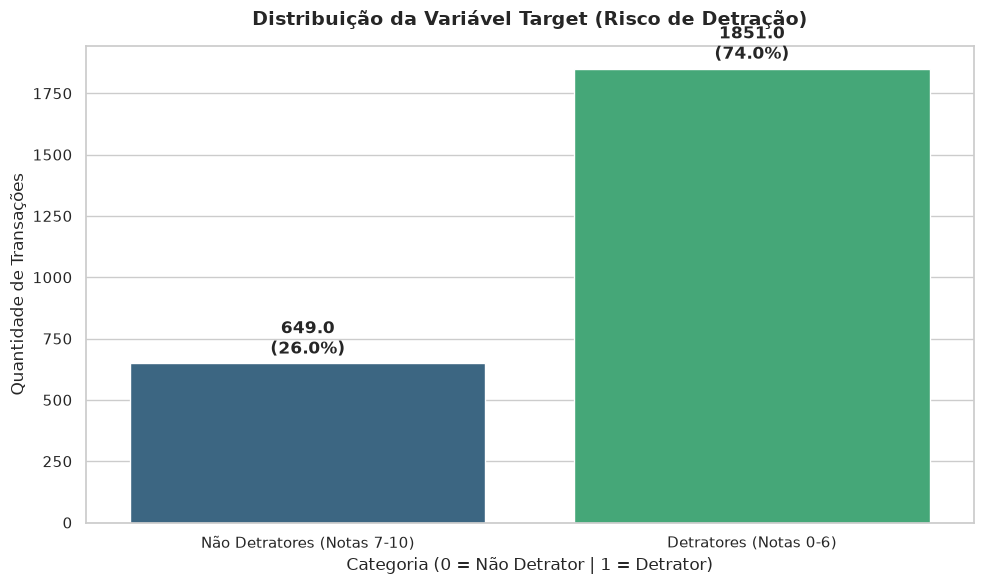

In [4]:
# Criando a coluna alvo binária
df["is_detractor"] = (df["nps_score"] <= 6).astype(int)

# Estatísticas de distribuição
counts = df["is_detractor"].value_counts()
pcts = df["is_detractor"].value_counts(normalize=True) * 100

print(f"Distribuição da Target:")
print(f"- Não Detrator (0): {counts[0]} ({pcts[0]:.2f}%)")
print(f"- Detrator (1): {counts[1]} ({pcts[1]:.2f}%)")

# Gráfico da distribuição da Target
ax = sns.countplot(x="is_detractor", data=df, palette="viridis")
plt.title("Distribuição da Variável Target (Risco de Detração)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Categoria (0 = Não Detrator | 1 = Detrator)", fontsize=12)
plt.ylabel("Quantidade de Transações", fontsize=12)
plt.xticks([0, 1], ["Não Detratores (Notas 7-10)", "Detratores (Notas 0-6)"])

# Adicionando rótulos de valores em cima das barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}\n({height/len(df)*100:.1f}%)',
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Segmentações Categóricas de Risco Operacional
Para apoiar a análise exploratória estatística (AED) que realizaremos nas próximas etapas do projeto, vamos agrupar as métricas contínuas em faixas operacionais de risco.

In [5]:
def group_delivery_delay(days):
    if days == 0:
        return "Sem Atraso"
    elif 1 <= days <= 2:
        return "Atraso Baixo (1-2 dias)"
    elif 3 <= days <= 4:
        return "Atraso Médio (3-4 dias)"
    else:
        return "Atraso Crítico (5+ dias)"

def group_contacts(contacts):
    if contacts == 0:
        return "Sem Contato"
    elif 1 <= contacts <= 2:
        return "Contato Baixo (1-2 contatos)"
    elif 3 <= contacts <= 4:
        return "Contato Médio (3-4 contatos)"
    else:
        return "Contato Alto (5+ contatos)"

def group_support(days):
    if days <= 2:
        return "Rápido (0-2 dias)"
    elif 3 <= days <= 5:
        return "Médio (3-5 dias)"
    elif 6 <= days <= 8:
        return "Lento (6-8 dias)"
    else:
        return "Crítico (9+ dias)"

# Aplicando os mapeamentos
df["delay_group"] = df["delivery_delay_days"].apply(group_delivery_delay)
df["contacts_group"] = df["customer_service_contacts"].apply(group_contacts)
df["support_group"] = df["resolution_time_days"].apply(group_support)

print("Segmentações criadas com sucesso!")
df[["customer_id", "delivery_delay_days", "delay_group", 
    "customer_service_contacts", "contacts_group", 
    "resolution_time_days", "support_group"]].sample(5)

Segmentações criadas com sucesso!


,customer_id,delivery_delay_days,delay_group,customer_service_contacts,contacts_group,resolution_time_days,support_group
491,492,0,Sem Atraso,1,Contato Baixo (1-2 contatos),10,Crítico (9+ dias)
1042,1043,3,Atraso Médio (3-4 dias),0,Sem Contato,7,Lento (6-8 dias)
696,697,1,Atraso Baixo (1-2 dias),1,Contato Baixo (1-2 contatos),2,Rápido (0-2 dias)
1855,1856,1,Atraso Baixo (1-2 dias),2,Contato Baixo (1-2 contatos),2,Rápido (0-2 dias)
1496,1497,4,Atraso Médio (3-4 dias),4,Contato Médio (3-4 contatos),7,Lento (6-8 dias)


## 5. Salvamento e Exportação da Base Higienizada
Agora, vamos persistir os dados tratados na pasta processed para que possam ser consumidos diretamente pela nossa etapa de EDA e de Modelagem Preditiva.

In [6]:
PROCESSED_DIR = BASE_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = PROCESSED_DIR / "processed_nps_data.csv"
df.to_csv(OUTPUT_FILE, index=False)

print(f"✓ Processo Concluído com Sucesso!")
print(f"Base higienizada e persistida em: {OUTPUT_FILE.resolve()}")

✓ Processo Concluído com Sucesso!
Base higienizada e persistida em: /home/userdev/dev/projetos/POSTECH_AI_SCIENTIST/TECH_CHALLENGE_ECOMMERCE/data/processed/processed_nps_data.csv
